# 05_regressor_embeddings_plus_metadata.ipynb

**Modelo 3: RS Embeddings + Metadata (Hybrid)**

## Features:
- **RS Embeddings**: 64 dimensiones (del modelo Two-Tower)
- **Metadata**: 6 features
  - `price`: Precio del juego
  - `early_access`: Early access (0/1)
  - `num_genres`: Cantidad de gÃ©neros
  - `num_tags`: Cantidad de tags
  - `num_specs`: Cantidad de especificaciones
  - `has_sentiment`: Tiene reviews (0/1)

**Total: 70 dimensiones**

## Target:
- `total_reviews`: Conteo de interacciones por juego

## Objetivo:
- Evaluar si combinar RS embeddings + metadata mejora el baseline
- Comparar con Modelo 1 (RS only) y Modelo 2 (Metadata only)

In [1]:
import pandas as pd
import numpy as np
import json
import ast

INTERACTIONS = "../Data/interactions.parquet"
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB = "../Data/item_embeddings_rs_clean.npy"
STEAM_GAMES = "../Data/steam_games.json"

# Load data
df_inter = pd.read_parquet(INTERACTIONS)
item_emb = np.load(ITEM_EMB)

with open(USERMAP,"r") as f: 
    user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: 
    item2idx = {k:int(v) for k,v in json.load(f).items()}

# Target: total reviews per game
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"âœ… Data loaded:")
print(f"   Total items with interactions: {len(target_df)}")
print(f"   RS Embeddings shape: {item_emb.shape}")

âœ… Data loaded:
   Total items with interactions: 3682
   RS Embeddings shape: (3682, 64)


## Load and preprocess metadata

In [2]:
# Leer el archivo lÃ­nea por lÃ­nea (formato Python dict)
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_games = pd.json_normalize(games)
df_games = df_games.rename(columns={"id":"item_id"})
df_games["item_idx"] = df_games["item_id"].map(item2idx)
df_games = df_games.dropna(subset=["item_idx"])
df_games["item_idx"] = df_games["item_idx"].astype(int)

# Parse release dates for temporal split
df_games['release_date_parsed'] = pd.to_datetime(df_games['release_date'], errors='coerce')

# Limpiar columna price
def clean_price(price):
    if pd.isna(price) or price == 'Free' or price == '':
        return 0.0
    if isinstance(price, (int, float)):
        return float(price)
    price_str = str(price).replace('$', '').replace('â‚¬', '').replace(',', '').strip()
    try:
        return float(price_str)
    except:
        return 0.0

df_games['price'] = df_games['price'].apply(clean_price)
df_games['early_access'] = df_games['early_access'].astype(int)

# Extraer features adicionales de metadata
def safe_len(x):
    try:
        if isinstance(x, list):
            return len(x)
        return 0
    except:
        return 0

df_games['num_genres'] = df_games['genres'].apply(safe_len)
df_games['num_tags'] = df_games['tags'].apply(safe_len)
df_games['num_specs'] = df_games['specs'].apply(safe_len)
df_games['has_sentiment'] = df_games['sentiment'].notna().astype(int)

print(f"\nðŸ“Š Metadata loaded:")
print(f"   Total games: {len(df_games)}")
print(f"   Games with valid dates: {df_games['release_date_parsed'].notna().sum()}")
print(f"   Metadata features: 6 (price, early_access, num_genres, num_tags, num_specs, has_sentiment)")


ðŸ“Š Metadata loaded:
   Total games: 3195
   Games with valid dates: 3107
   Metadata features: 6 (price, early_access, num_genres, num_tags, num_specs, has_sentiment)


## Combinar RS Embeddings + Metadata

In [3]:
# Preparar metadata features
meta = df_games[["item_idx", "price", "early_access", "num_genres", "num_tags", 
                 "num_specs", "has_sentiment", "release_date_parsed", "app_name"]]
meta = meta.set_index("item_idx").reindex(range(len(item_emb)))

# Features de metadata
feature_cols = ["price", "early_access", "num_genres", "num_tags", "num_specs", "has_sentiment"]
meta_features = meta[feature_cols].fillna(0).values

# Combinar RS embeddings (64-dim) + metadata (6-dim) = 70-dim
X = np.hstack([item_emb, meta_features])

# Target: total reviews
y = target_df.set_index("item_idx").loc[range(len(item_emb))]["total_reviews"].values

# Merge con metadata para temporal split
item_indices = list(range(len(item_emb)))
data_df = pd.DataFrame({
    'item_idx': item_indices,
    'total_reviews': y
})

data_df = data_df.merge(
    meta.reset_index()[['item_idx', 'release_date_parsed', 'app_name']],
    on='item_idx',
    how='left'
)

print(f"\nâœ… Features prepared:")
print(f"   RS Embeddings: {item_emb.shape[1]} dimensions")
print(f"   Metadata: {meta_features.shape[1]} dimensions")
print(f"   Combined X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Target range: {y.min()} - {y.max()}")
print(f"   Items with dates: {data_df['release_date_parsed'].notna().sum()}")


âœ… Features prepared:
   RS Embeddings: 64 dimensions
   Metadata: 6 dimensions
   Combined X shape: (3682, 70)
   y shape: (3682,)
   Target range: 1 - 3759
   Items with dates: 3107


## Train Model - TEMPORAL SPLIT

**Estrategia de validaciÃ³n temporal:**
- Train: Juegos lanzados ANTES de 2016-01-01
- Test: Juegos lanzados DESPUÃ‰S (todo 2017)

In [4]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Define temporal cutoff
cutoff_date = pd.to_datetime('2016-01-01')

# Create temporal train/test split
train_mask = data_df['release_date_parsed'] < cutoff_date
test_mask = data_df['release_date_parsed'] >= cutoff_date

# Remove items without valid dates
valid_dates_mask = data_df['release_date_parsed'].notna()
train_mask = train_mask & valid_dates_mask
test_mask = test_mask & valid_dates_mask

X_train_temporal = X[train_mask]
X_test_temporal = X[test_mask]
y_train_temporal = y[train_mask]
y_test_temporal = y[test_mask]

print(f"{'='*70}")
print("TEMPORAL SPLIT SUMMARY")
print(f"{'='*70}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train set: {len(X_train_temporal)} games (released before {cutoff_date.date()})")
print(f"Test set: {len(X_test_temporal)} games (released after {cutoff_date.date()})")
print(f"Train target: {y_train_temporal.min():.0f} - {y_train_temporal.max():.0f} (mean: {y_train_temporal.mean():.1f})")
print(f"Test target: {y_test_temporal.min():.0f} - {y_test_temporal.max():.0f} (mean: {y_test_temporal.mean():.1f})")
print(f"{'='*70}\n")

# Train model on temporal split
# ─── Optuna: Busqueda de Hiperparametros ─────────────────────────────────────
import optuna
from sklearn.metrics import mean_squared_error as _mse_opt_
optuna.logging.set_verbosity(optuna.logging.WARNING)

_n_tr      = len(X_train_temporal)
_split_idx = max(10, int(_n_tr * 0.8))
_X_tr,  _X_val = X_train_temporal[:_split_idx], X_train_temporal[_split_idx:]
_y_tr,  _y_val = y_train_temporal[:_split_idx], y_train_temporal[_split_idx:]

def _objective(trial):
    _p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 800),
        learning_rate    = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        random_state=42, tree_method='hist', verbosity=0,
    )
    _m = XGBRegressor(**_p)
    _m.fit(_X_tr, _y_tr)
    return float(_mse_opt_(_y_val, _m.predict(_X_val)) ** 0.5)

_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42))
_study.optimize(_objective, n_trials=50, show_progress_bar=True)

best_params = {**_study.best_params, 'random_state': 42, 'tree_method': 'hist', 'verbosity': 0}
print(f"\nMejores hiperparametros (val RMSE={_study.best_value:.2f}):")
for _k, _v in best_params.items():
    print(f"  {_k}: {_v}")

model_temporal = XGBRegressor(**best_params)

print("Training model on games released before cutoff...")
model_temporal.fit(X_train_temporal, y_train_temporal)

pred_temporal = model_temporal.predict(X_test_temporal)

mse_temporal = mean_squared_error(y_test_temporal, pred_temporal)
rmse_temporal = np.sqrt(mse_temporal)
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print("\n" + "="*70)
print("RS EMBEDDINGS + METADATA - TEMPORAL VALIDATION")
print("="*70)
print(f"RMSE: {rmse_temporal:.2f}")
print(f"RÂ²: {r2_temporal:.6f}")
print("="*70)

C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TEMPORAL SPLIT SUMMARY
Cutoff date: 2016-01-01
Train set: 2621 games (released before 2016-01-01)
Test set: 486 games (released after 2016-01-01)
Train target: 1 - 3759 (mean: 17.3)
Test target: 1 - 1050 (mean: 10.5)



  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 1.04171:   0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 1.04171:   2%|▏         | 1/50 [00:00<00:23,  2.12it/s]

...

Best trial: 47. Best value: 0.712308:  98%|█████████▊| 49/50 [00:41<00:00,  1.21it/s]

Best trial: 47. Best value: 0.712308: 100%|██████████| 50/50 [00:41<00:00,  1.46it/s]

Best trial: 47. Best value: 0.712308: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


Mejores hiperparametros (val RMSE=0.71):
  n_estimators: 520
  learning_rate: 0.10165215975037514
  max_depth: 7
  min_child_weight: 8
  subsample: 0.593847617575133
  colsample_bytree: 0.667206744005043
  gamma: 0.08191472541622719
  random_state: 42
  tree_method: hist
  verbosity: 0
Training model on games released before cutoff...



RS EMBEDDINGS + METADATA - TEMPORAL VALIDATION
RMSE: 62.57
RÂ²: -0.209617


## VisualizaciÃ³n de Resultados

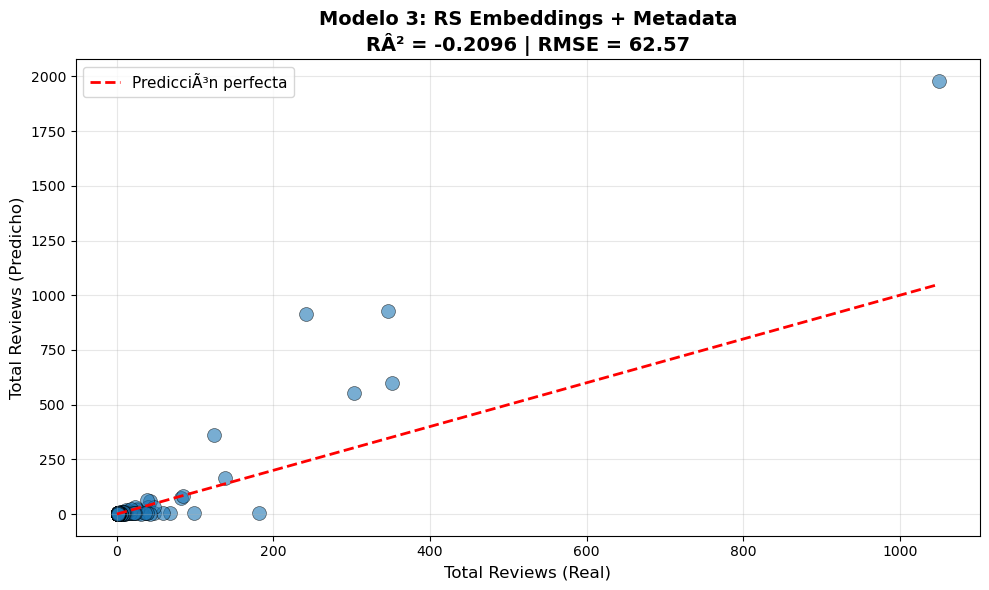


ðŸ“Š RESUMEN - Modelo 3: RS Embeddings + Metadata (Hybrid)
Features: RS Embeddings (64-dim) + Metadata (6-dim)
          Total: 70 dimensiones
Train: 2621 juegos (antes de 2016-01-01)
Test: 486 juegos (2016 en adelante)

Resultados:
  RÂ² = -0.2096
  RMSE = 62.57

ComparaciÃ³n con Modelo 1 (RS only):
  Modelo 1 - RÂ²: 0.6422, RMSE: 94.17
  Modelo 3 - RÂ²: -0.2096, RMSE: 62.57
  âš ï¸  DisminuciÃ³n de 132.6% en RÂ²


In [5]:
import matplotlib.pyplot as plt

# Crear grÃ¡fico de predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
plt.plot([0, y_test_temporal.max()], [0, y_test_temporal.max()], 'r--', lw=2, label='PredicciÃ³n perfecta')
plt.xlabel('Total Reviews (Real)', fontsize=12)
plt.ylabel('Total Reviews (Predicho)', fontsize=12)
plt.title(f'Modelo 3: RS Embeddings + Metadata\nRÂ² = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ðŸ“Š RESUMEN - Modelo 3: RS Embeddings + Metadata (Hybrid)")
print("="*70)
print(f"Features: RS Embeddings (64-dim) + Metadata (6-dim)")
print(f"          Total: 70 dimensiones")
print(f"Train: {len(X_train_temporal)} juegos (antes de 2016-01-01)")
print(f"Test: {len(X_test_temporal)} juegos (2016 en adelante)")
print(f"\nResultados:")
print(f"  RÂ² = {r2_temporal:.4f}")
print(f"  RMSE = {rmse_temporal:.2f}")
print(f"\nComparaciÃ³n con Modelo 1 (RS only):")
print(f"  Modelo 1 - RÂ²: 0.6422, RMSE: 94.17")
print(f"  Modelo 3 - RÂ²: {r2_temporal:.4f}, RMSE: {rmse_temporal:.2f}")
if r2_temporal > 0.6422:
    print(f"  âœ… Mejora de {((r2_temporal - 0.6422) / 0.6422 * 100):.1f}% en RÂ²")
else:
    print(f"  âš ï¸  DisminuciÃ³n de {((0.6422 - r2_temporal) / 0.6422 * 100):.1f}% en RÂ²")
print("="*70)

In [6]:
# ─── Métricas adicionales + TSCV + KFold ────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold
from scipy.stats import spearmanr

# 1. Extra metrics on temporal split
mae_temporal   = mean_absolute_error(y_test_temporal, pred_temporal)
mape_temporal  = mean_absolute_percentage_error(y_test_temporal, pred_temporal)
spear_temporal, _ = spearmanr(y_test_temporal, pred_temporal)
print("="*70)
print("METRICAS ADICIONALES - SPLIT TEMPORAL")
print("="*70)
print(f"MAE:      {mae_temporal:.2f}")
print(f"MAPE:     {mape_temporal * 100:.1f}%")
print(f"Spearman: {spear_temporal:.4f}")

# 2. TSCV
cutoff_windows = [
    ('2013-07-01', '2014-01-01'),
    ('2014-01-01', '2014-07-01'),
    ('2014-07-01', '2015-01-01'),
    ('2015-01-01', '2015-07-01'),
    ('2015-07-01', '2016-01-01'),
]
item_dates_ts = data_df['release_date_parsed'].values

print("\n" + "="*70)
print("TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)")
print("="*70)
ts_results = []
for i, (tc, sc) in enumerate(cutoff_windows, 1):
    tc, sc = pd.Timestamp(tc), pd.Timestamp(sc)
    t_mask = np.array([pd.notna(d) and d < tc for d in item_dates_ts])
    e_mask = np.array([pd.notna(d) and d >= tc and d < sc for d in item_dates_ts])
    if e_mask.sum() < 5:
        print(f"  W{i}: skipped ({e_mask.sum()} eval games)")
        continue
    Xtr, Xte = X[t_mask], X[e_mask]
    ytr, yte = y[t_mask], y[e_mask]
    if len(ytr) == 0:
        continue
    m_ts = XGBRegressor(**best_params)
    m_ts.fit(Xtr, ytr)
    pred_ts = m_ts.predict(Xte)
    r2_ts   = r2_score(yte, pred_ts)
    rmse_ts = mean_squared_error(yte, pred_ts) ** 0.5
    ts_results.append({'Fold': i, 'R2': r2_ts, 'RMSE': rmse_ts})
    print(f"  W{i} ({tc.date()} -> {sc.date()}): n={e_mask.sum():3d} | R2={r2_ts:.4f} | RMSE={rmse_ts:.2f}")

if ts_results:
    ts_df = pd.DataFrame(ts_results)
    r2_tscv_mean   = ts_df['R2'].mean();  r2_tscv_std    = ts_df['R2'].std()
    rmse_tscv_mean = ts_df['RMSE'].mean(); rmse_tscv_std  = ts_df['RMSE'].std()
    print(f"\n  -> TSCV R2 = {r2_tscv_mean:.4f} +/- {r2_tscv_std:.4f}  RMSE = {rmse_tscv_mean:.2f}")
else:
    r2_tscv_mean = r2_tscv_std = rmse_tscv_mean = rmse_tscv_std = float('nan')
    print("  Sin suficientes datos para TSCV")

# 3. KFold
valid_dt_mask = np.array([pd.notna(d) for d in data_df['release_date_parsed'].values])
X_kf = X[valid_dt_mask];  y_kf = y[valid_dt_mask]

print("\n" + "="*70)
print("K-FOLD CROSS VALIDATION (5 folds)")
print("="*70)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_results = []
for fold, (tr_idx, te_idx) in enumerate(kf.split(X_kf), 1):
    m_kf = XGBRegressor(**best_params)
    m_kf.fit(X_kf[tr_idx], y_kf[tr_idx])
    pred_kf = m_kf.predict(X_kf[te_idx])
    r2_kf   = r2_score(y_kf[te_idx], pred_kf)
    rmse_kf = mean_squared_error(y_kf[te_idx], pred_kf) ** 0.5
    kf_results.append({'Fold': fold, 'R2': r2_kf, 'RMSE': rmse_kf})
    print(f"  Fold {fold}: R2={r2_kf:.4f} | RMSE={rmse_kf:.2f}")
kf_df = pd.DataFrame(kf_results)
r2_kfold_mean   = kf_df['R2'].mean();  r2_kfold_std    = kf_df['R2'].std()
rmse_kfold_mean = kf_df['RMSE'].mean()
print(f"\n  -> KFold R2 = {r2_kfold_mean:.4f} +/- {r2_kfold_std:.4f}  RMSE = {rmse_kfold_mean:.2f}")


METRICAS ADICIONALES - SPLIT TEMPORAL
MAE:      9.23
MAPE:     49.8%
Spearman: 0.5946

TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)


  W1 (2013-07-01 -> 2014-01-01): n=222 | R2=0.1278 | RMSE=73.63


  W2 (2014-01-01 -> 2014-07-01): n=280 | R2=-2.9174 | RMSE=73.77


  W3 (2014-07-01 -> 2015-01-01): n=299 | R2=-1.1917 | RMSE=26.60


  W4 (2015-01-01 -> 2015-07-01): n=343 | R2=-1.4652 | RMSE=41.59


...

  Fold 1: R2=-0.7008 | RMSE=78.12


  Fold 2: R2=0.5124 | RMSE=108.13


  Fold 3: R2=-1.9622 | RMSE=55.63


  Fold 4: R2=0.5115 | RMSE=123.09


  Fold 5: R2=-0.1818 | RMSE=44.15

  -> KFold R2 = -0.3642 +/- 1.0290  RMSE = 81.82


In [7]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
from results_tracker import save_result, print_leaderboard

save_result(
    model_id="05",
    model_name="RS + Metadata",
    features="RS clean (64d) + Metadata (6d)",
    embeddings="clean",
    metrics={
        "r2_temporal":   r2_temporal,
        "rmse_temporal": rmse_temporal,
        "mae_temporal":  mae_temporal,
        "mape_temporal": mape_temporal,
        "r2_tscv":       r2_tscv_mean,
        "r2_tscv_std":   r2_tscv_std,
        "rmse_tscv":     rmse_tscv_mean,
        "rmse_tscv_std": rmse_tscv_std,
        "r2_kfold":      r2_kfold_mean,
        "r2_kfold_std":  r2_kfold_std,
        "rmse_kfold":    rmse_kfold_mean,
    },
)
print_leaderboard()


 ID  Modelo                         R2 test     RMSE     MAE   MAPE%   R2 TSCV  R2 KFold
[10]  RS + Reviews + RAWG             0.9379    14.18    2.52    29.3    0.7678    0.5072
[09]  RS + Review Text                0.9066    17.38    3.00    28.2    0.8633    0.3030
[03]  RS Embeddings Only              0.5248    39.22    5.84     0.5    0.6651    0.3747
[08]  Hybrid Collab-Content           0.4489    42.24    5.88     0.4    0.3747    0.4410
[04]  Metadata Only                   0.0653    55.00   19.62     8.3   -0.5163    0.0599
[06]  Review Text Emb                -0.0001    56.90   18.22     8.2   -0.1168   -0.0001
[05]  RS + Metadata                  -0.2096    62.57    9.23     0.5   -0.9298   -0.3642
[07]  Tag Embeddings                -127.2421    65.09   14.09     4.6  -22.5516   -0.0710
